## Cell 1 — Imports & setup

In [25]:
# Cell 1 — imports
import os
import pandas as pd
import numpy as np

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8,5), "figure.dpi": 120})


## Cell 2 — Load cleaned ratings & movies

In [26]:
# Cell 2 — load data (prefer filtered ratings if available)
import os
ratings_path = 'data/processed/ratings_filtered.csv' if os.path.exists('data/processed/ratings_filtered.csv') else 'data/processed/ratings_clean.csv'
ratings = pd.read_csv(ratings_path)
movies = pd.read_csv('data/processed/movies_meta.csv')
print('Loaded ratings from', ratings_path)

ratings.head()


Loaded ratings from data/processed/ratings_filtered.csv


,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


## STEP 1 — Load Data into Surprise

In [27]:
# Cell 3 — Surprise dataset
reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

trainset = data.build_full_trainset()

print("Number of users:", trainset.n_users)
print("Number of items:", trainset.n_items)
print("Number of ratings:", trainset.n_ratings)


Number of users: 943
Number of items: 1349
Number of ratings: 99287


## STEP 2 — Train SVD Model

In [28]:
# Cell 4 — train SVD model
# Using tuned hyperparameters from tuning cell: n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.05
algo = SVD(
    n_factors=50,
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.05,
    random_state=42
)

algo.fit(trainset)

print("SVD model training completed.")


SVD model training completed.


In [29]:
# Hyperparameter Tuning (SVD) — tune n_epochs, lr_all, reg_all
from surprise import accuracy
from surprise.model_selection import train_test_split

# Prepare a train/test split for tuning (keeps main `trainset` untouched)
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

best_rmse = float('inf')
best_params = None
results = []
for n_epochs in [20, 30]:
    for lr in [0.002, 0.005]:
        for reg in [0.02, 0.05]:
            model = SVD(n_factors=50, n_epochs=n_epochs, lr_all=lr, reg_all=reg, random_state=42)
            model.fit(train_data)
            preds = model.test(test_data)
            rmse = accuracy.rmse(preds, verbose=False)
            results.append((n_epochs, lr, reg, rmse))
            print(f"n_epochs={n_epochs}, lr={lr}, reg={reg} -> RMSE={rmse:.4f}")
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = dict(n_epochs=n_epochs, lr=lr, reg=reg)

print('')
print('Best tuning result:')
print(best_params, 'RMSE=', best_rmse)
# expose tuning results for later use
tuning_results = results
tuning_best = (best_params, best_rmse)


n_epochs=20, lr=0.002, reg=0.02 -> RMSE=0.9428
n_epochs=20, lr=0.002, reg=0.05 -> RMSE=0.9423
n_epochs=20, lr=0.005, reg=0.02 -> RMSE=0.9290
n_epochs=20, lr=0.005, reg=0.05 -> RMSE=0.9271
n_epochs=30, lr=0.002, reg=0.02 -> RMSE=0.9374
n_epochs=30, lr=0.002, reg=0.05 -> RMSE=0.9369
n_epochs=30, lr=0.005, reg=0.02 -> RMSE=0.9348
n_epochs=30, lr=0.005, reg=0.05 -> RMSE=0.9171

Best tuning result:
{'n_epochs': 30, 'lr': 0.005, 'reg': 0.05} RMSE= 0.9171059431625257


## (Recommended) Evaluate model performance

In [30]:
# Cell 5 — train-test evaluation
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# Evaluate using the tuned hyperparameters for consistency
algo_eval = SVD(n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.05, random_state=42)
algo_eval.fit(train_data)

predictions = algo_eval.test(test_data)
rmse = accuracy.rmse(predictions)


RMSE: 0.9171


In [31]:
from surprise import accuracy

# Calculate MAE
mae = accuracy.mae(predictions)
print(f"MAE: {mae:.4f}")

# Calculate R²
def calculate_r_squared(predictions):
    y_true = [pred.r_ui for pred in predictions]
    y_pred = [pred.est for pred in predictions]
    y_mean = sum(y_true) / len(y_true)
    
    ss_total = sum((y - y_mean) ** 2 for y in y_true)
    ss_res = sum((y_true[i] - y_pred[i]) ** 2 for i in range(len(y_true)))
    
    r_squared = 1 - (ss_res / ss_total)
    return r_squared

r_squared = calculate_r_squared(predictions)
print(f"R²: {r_squared:.4f}")

MAE:  0.7248
MAE: 0.7248
R²: 0.3254


## STEP 3 — Rating Prediction Function

In [32]:
# Cell 6 — predict rating
def predict_rating(user_id, movie_id):
    """
    Predict rating a user would give to a movie
    """
    return algo.predict(user_id, movie_id).est

predict_rating(user_id=1, movie_id=50)


5

## STEP 4 — Top-N Recommendation Function (Collaborative Filtering)

In [33]:
# Cell 7 — Top-N CF recommender
def recommend_cf(user_id, n=10):
    """
    Recommend top-N movies to a user using collaborative filtering
    """
    # movies already rated by user
    rated_movie_ids = ratings[ratings['userId'] == user_id]['movieId'].unique()

    # unseen movies
    unseen_movies = movies[~movies['movieId'].isin(rated_movie_ids)].copy()

    # predict ratings for unseen movies
    unseen_movies['predicted_rating'] = unseen_movies['movieId'].apply(
        lambda movie_id: algo.predict(user_id, movie_id).est
    )

    # sort by predicted rating
    recommendations = unseen_movies.sort_values(
        by='predicted_rating',
        ascending=False
    ).head(n)

    return recommendations[['movieId', 'title', 'predicted_rating']]

recommend_cf(user_id=1, n=10)



,movieId,title,predicted_rating
284,285,Secrets & Lies (1996),4.676898
602,603,Rear Window (1954),4.667478
640,641,Paths of Glory (1957),4.647249
482,483,Casablanca (1942),4.620712
407,408,"Close Shave, A (1995)",4.611896
511,512,Wings of Desire (1987),4.606517
473,474,Dr. Strangelove or: How I Learned to Stop Worr...,4.561979
426,427,To Kill a Mockingbird (1962),4.529582
510,511,Lawrence of Arabia (1962),4.495694
301,302,L.A. Confidential (1997),4.491600


## Optional — Visualize recommendations

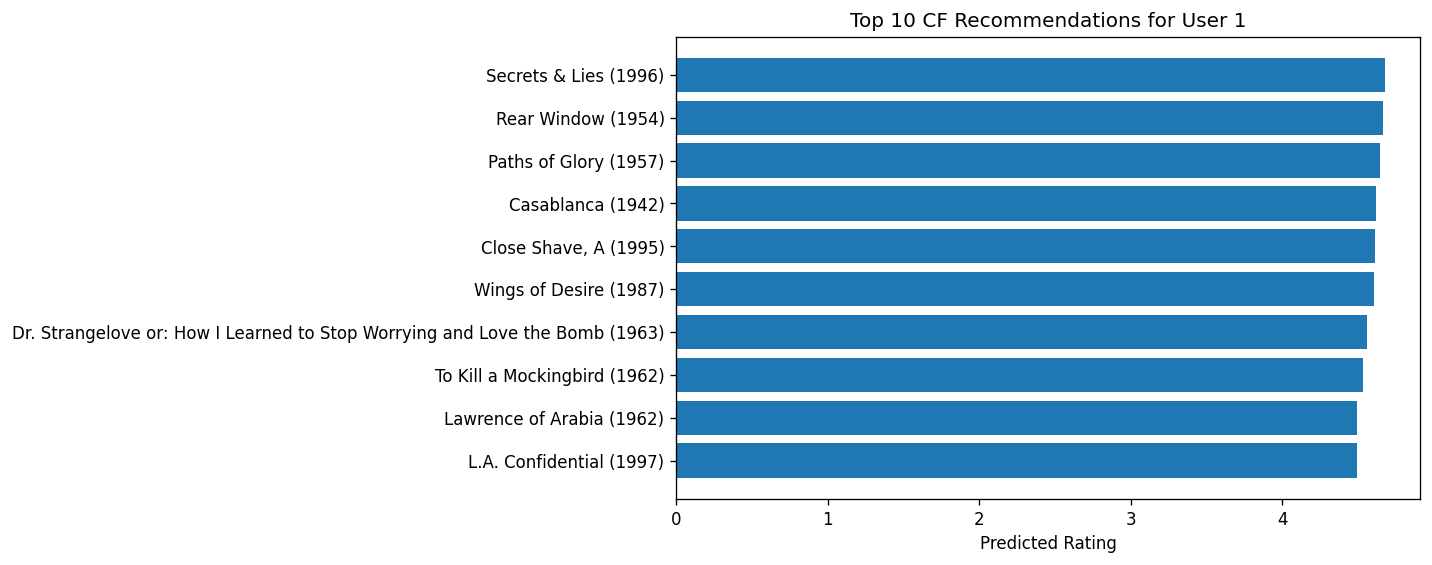

In [34]:
# Cell 9 — visualize recommendations
recs = recommend_cf(1, 10)

plt.barh(recs['title'][::-1], recs['predicted_rating'][::-1])
plt.xlabel("Predicted Rating")
plt.title("Top 10 CF Recommendations for User 1")
plt.show()


## Optional — Save trained model predictions (for hybrid phase)

In [35]:
# Cell 10 — save predictions (optional)
recs.to_csv("data/processed/sample_cf_recommendations.csv", index=False)
